# CatBoost 기반 네트워크 침입 탐지 앙상블 모델 (v6)

딥러닝(SSAE + DeepCNN) 모델에서 발견된 한계점(정상 데이터 오탐증가, SMOTE 부작용 등)을 해결하기 위해, **CatBoost** 앙상블 트리 적용.

- **RandomOverSampler**: 트리 모델은 합성 데이터의 중첩 공간에 민감할 수 있으므로, 원본 데이터를 단순 반복 튜플링하여 데이터 보완.
- **특징 변환기 분리**: 비지도 학습이 필요 없으며 원본의 70개 특징을 직접 주입하여 학습.
- **특징 중요도 도출**: 모델이 어떤 특징을 중요하게 생각하는지 직관적으로 분석.

## 1. 라이브러리 임포트

In [7]:
!pip install catboost
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler

from catboost import CatBoostClassifier

# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 재현성 고정
SEED = 42
np.random.seed(SEED)


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. 데이터 로드 및 분할

In [8]:
BASE_DIR   = os.path.dirname(os.path.abspath("__file__"))
OUTPUT_DIR = os.path.join(BASE_DIR, "processed")
MODEL_DIR  = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

X = np.load(os.path.join(OUTPUT_DIR, "X.npy"))
y = np.load(os.path.join(OUTPUT_DIR, "y.npy"))

with open(os.path.join(OUTPUT_DIR, "label_mapping.json"), encoding="utf-8") as f:
    label_mapping = json.load(f)

idx2label   = {v: k for k, v in label_mapping.items()}
class_names = [idx2label[i] for i in range(len(idx2label))]
num_classes = len(class_names)

# Train 70 / Val 15 / Test 15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print("원본 Train 데이터 분포:", Counter(y_train))

원본 Train 데이터 분포: Counter({np.int32(0): 350000, np.int32(4): 350000, np.int32(3): 350000, np.int32(2): 267253, np.int32(1): 200333, np.int32(5): 113354, np.int32(6): 700})


## 3. RandomOverSampler 적용

In [9]:
print("RandomOverSampler 데이터 증식 진행 중...")
ros = RandomOverSampler(random_state=SEED)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print("증식 적용 후 Train 데이터 분포:", Counter(y_train_res))

RandomOverSampler 데이터 증식 진행 중...
증식 적용 후 Train 데이터 분포: Counter({np.int32(0): 350000, np.int32(4): 350000, np.int32(2): 350000, np.int32(3): 350000, np.int32(1): 350000, np.int32(5): 350000, np.int32(6): 350000})


## 4. CatBoostClassifier 학습

In [10]:
print("\n=== CatBoost 앙상블 학습 시작 (진행률 출력) ===")

# CPU 또는 가용 시 GPU 사용 설정
cb_model = CatBoostClassifier(
    iterations=500,           # 너무 깊게 안 잡아도 우수한 성능 (오버피팅 방지)
    learning_rate=0.1,        # 적절한 학습률
    depth=8,                  # 트리의 깊이
    loss_function='MultiClass',
    custom_metric=['Accuracy', 'F1'],
    eval_metric='Accuracy',
    random_seed=SEED,
    early_stopping_rounds=30, # 조기 종료 지원
    task_type="GPU",          # CPU 학습 (GPU 지원 시 "GPU" 로 변경)
    verbose=50                # 50 step마다 출력
)

cb_model.fit(
    X_train_res, y_train_res,
    eval_set=(X_val, y_val),
    use_best_model=True,
    plot=False
)

# 모델 저장
cb_model.save_model(os.path.join(MODEL_DIR, "best_model_v6_catboost.cbm"))
print("\n학습 및 가중치 저장 완료!")


=== CatBoost 앙상블 학습 시작 (진행률 출력) ===
0:	learn: 0.8396543	test: 0.8144790	best: 0.8144790 (0)	total: 122ms	remaining: 1m
50:	learn: 0.8921722	test: 0.8689584	best: 0.8692901 (49)	total: 5.21s	remaining: 45.8s
100:	learn: 0.8996506	test: 0.8782108	best: 0.8783481 (99)	total: 9.83s	remaining: 38.8s
150:	learn: 0.9031763	test: 0.8856843	best: 0.8856843 (150)	total: 14.3s	remaining: 33.1s
200:	learn: 0.9047518	test: 0.8893710	best: 0.8893710 (200)	total: 18.8s	remaining: 27.9s
250:	learn: 0.9052290	test: 0.8902662	best: 0.8905522 (241)	total: 22.9s	remaining: 22.7s
bestTest = 0.8905522013
bestIteration = 241
Shrink model to first 242 iterations.

학습 및 가중치 저장 완료!


## 5. 모델 성능 평가 (Classification Report)

In [11]:
print("=== Classification Report (v6: RandomOverSampler + CatBoost) ===")

y_preds = cb_model.predict(X_test)
# catboost 예측 결과는 2차원 [N, 1] 형태이므로 1차원 평탄화
y_preds = y_preds.flatten()

print(classification_report(y_test, y_preds, target_names=class_names, digits=4))

=== Classification Report (v6: RandomOverSampler + CatBoost) ===
               precision    recall  f1-score   support

       Benign     0.9070    0.7125    0.7980     75000
          Bot     0.9989    0.9999    0.9994     42929
  Brute Force     0.8604    0.9579    0.9066     57269
         DDoS     0.9992    0.9998    0.9995     75000
          DoS     0.9660    0.8816    0.9219     75000
 Infiltration     0.4678    0.7740    0.5832     24290
SQL Injection     0.4902    1.0000    0.6579       150

     accuracy                         0.8903    349638
    macro avg     0.8128    0.9037    0.8381    349638
 weighted avg     0.9124    0.8903    0.8953    349638



## 6. 특징 중요도 (Feature Importances) 시각화

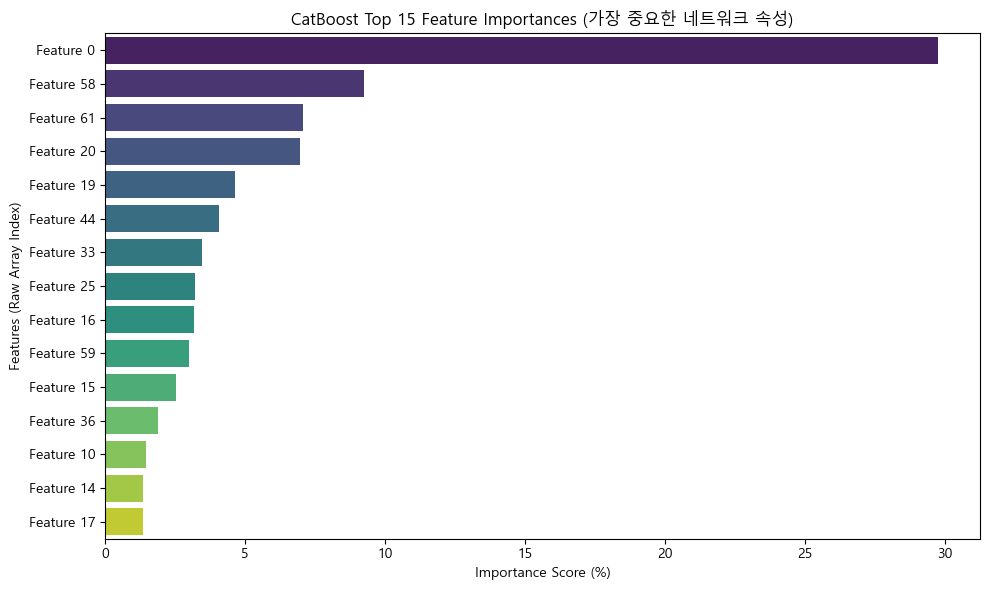

In [12]:
%matplotlib inline

feature_importances = cb_model.get_feature_importance()

# 중요도 기준 상위 15개 피처만 정렬하여 시각화
sorted_idx = np.argsort(feature_importances)[::-1][:15]
top_importances = feature_importances[sorted_idx]
top_features = [f"Feature {i}" for i in sorted_idx]

plt.figure(figsize=(10, 6))
sns.barplot(x=top_importances, y=top_features, palette="viridis")
plt.title("CatBoost Top 15 Feature Importances (가장 중요한 네트워크 속성)")
plt.xlabel("Importance Score (%)")
plt.ylabel("Features (Raw Array Index)")
plt.tight_layout()
plt.show()